# __Compte Rendu mini projet réchauffement climatique__
### Antoine Molines

## __Introduction__
Le but de ce mini projet est d'étuidier le réchauffement climatique et l'évolution des températures en utilisant les ajustements par moindre carrés, notamment en utilisant la fonction curve_fit. Nous allons utiliser comme données les températures enregistrées à la station météorologique de Montélimar au cours du denier siècle.

## __Ajustement linéaire__
Dans cette partie, nous ferons un ajustement linéaire des données afin d'étudier l'évolution des températures au cours de plusieurs années.\
Commencons par importer les modules et extraire les données du fichier:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit  #pour ajustement
import pandas as pd
import math
from datetime import datetime, timedelta 


date_jd, temp = np.loadtxt("montelimar_temperature.dat", unpack = True)   #extracation

Nous avons extrait les données en 2 colonnes séparées pour pouvoir les manipuler individuellement. Aussi, la colonne des dates est en format MJD, qu'il faut convertir en date, nous créeons donc des fonctions pour la conversion, et créeons un tableau numpy des dates traitées:

In [3]:
def mjd_to_jd(mjd):               #fonction pour converitr le format MJD en JD
    return mjd + 2400000.5


date_new=mjd_to_jd(date_jd)


def date_normale(jd):     #fonction pour convertir en format des dates normales
    JD_0 = 1721425.5
    days_since_jd_0 = jd - JD_0
    date = datetime(1, 1, 1) + timedelta(days=days_since_jd_0)
    return date


date = np.array([date_normale(jd)for jd in date_new])   #tableau des dates

Dans un premier temps, pour l'ajustement linéaire, nous allons tracer les moyenens de températures par années, il nous faut donc isoler les années:

In [4]:
years= np.array([d.year for d in date])

Nous pouvons donc maintenant calculer la moyenne de température par année:

In [5]:
moyennes = []          #initialision
for annee in np.unique(years):          #boucle
    
    temp_an = temp[years == annee]        #création d'un tableau de booléen pour comparer

    moyennes.append(np.mean(temp_an))        #ajout de la moyenne

moyenne_tab=np.array(moyennes)    #tableau


Nous pouvons donc maintenant tracer la température moyenne par année au cours du dernier siècle:

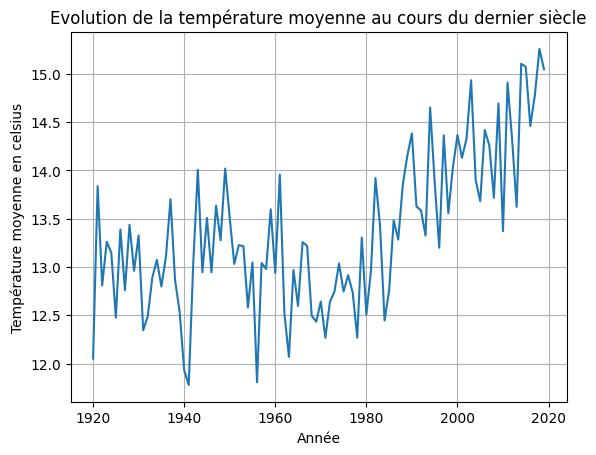

In [6]:
plt.figure()
plt.plot(np.unique(years), moyenne_tab,  )
plt.xlabel("Année")
plt.ylabel("Température moyenne en celsius")
plt.grid()
plt.title("Evolution de la température moyenne au cours du dernier siècle")
plt.show()

Nous voulons savoir par exemple, l'évolution de la température moyenne au cours des 30 dernières années. Pour cela, nous allons faire un ajustement par un modèle linéaire et extraire les paramètres ajustés:

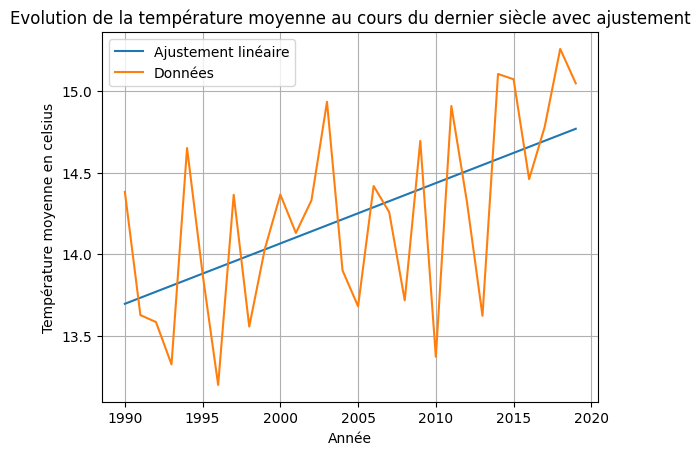

coefficient directeur: 0.03698816785265291 ± 0.01055403630861276
augemtnation de  1.1096450355795873 ± 0.3166210892583828 degrès en 30 ans


In [7]:
#Isoler vealeurs pour 30 ans
année=np.unique(years).tolist()
année_30=année[-30:]
année_30_tab=np.array(année_30)
moyennes_30=moyennes[-30:]
moyennes_30_tab=np.array(moyennes_30)
afit=np.arange(1990,2020,1)

#définition du modèle d'ajustement
def modlin(x, a, b):
    return b + a * x

#ajustment
fit = curve_fit(modlin, année_30_tab, moyennes_30_tab)
para, pcov = fit  #paramètres ajustées

a=para[0]
b=para[1]
sig= np.sqrt(np.diag(pcov))

#tracage de l'ajustement
tfit= modlin(afit, a, b)  
plt.figure()
plt.plot(afit,tfit, label='Ajustement linéaire')
plt.plot(année_30_tab,moyennes_30_tab, label="Données")
plt.legend()
plt.xlabel("Année")
plt.ylabel("Température moyenne en celsius")
plt.title("Evolution de la température moyenne au cours du dernier siècle avec ajustement")
plt.grid()
plt.show()
print("coefficient directeur:",a, "\u00B1", sig[0])
print("augemtnation de ",30*a,"\u00B1", 30*sig[0],"degrès en 30 ans")

Le paramètre extrait de l'ajustement correspond au coefficent directeur, nous voyons donc qu'en 30 ans, la température moyenne a augementée d'environ 1 degrès celsius.

## __Ajustement sinuosidal__
Dans cette partie, nous allons faire l'ajustement de l'evolution des températures par un modèle sinuosidal: $$ T(t) = A \sin{(\omega t + \phi)} + B + C t $$ où le coefficient $C$ traduirera l'augmentation générale des températures.

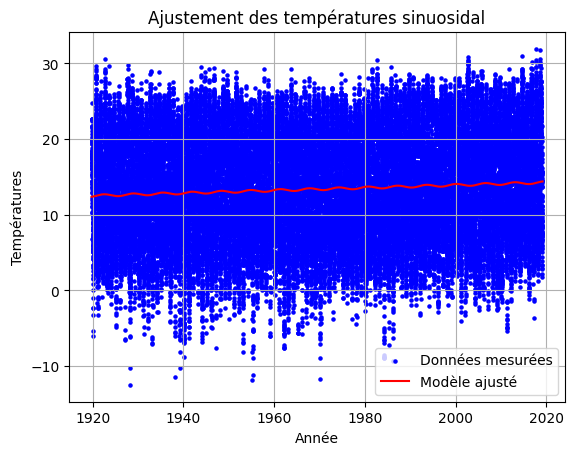

les paramètres ajustés sont [ 1.53379888e-01  9.71446041e-01  5.66785670e+01 -2.13062689e+01
  1.76056020e-02]
En 30 ans, on a une augmentation de  0.5281680586420711 avec une incertitude de 0.039195542673493663


In [25]:
dates_years = 1858 + (date_jd / 365.25)

#modèle sinusoidal avec tendance linéaire
def model(t, A, omega, phi, B, C):
    return A * np.sin(omega * t + phi) + B + C * t



#ajustement du modèle aux données
params, covariance = curve_fit(model, dates_years, temp,)

#Prédictions du modèle ajusté
temps_fit = np.linspace(min(dates_years), max(dates_years), 1000)
temperatures_fit = model(temps_fit, *params)

sig= np.sqrt(np.diag(covariance))

plt.figure()
plt.scatter(dates_years, temp, s=5, color="blue", label="Données mesurées")
plt.plot(temps_fit, temperatures_fit, color="red", label="Modèle ajusté")
plt.xlabel("Année")
plt.ylabel("Températures")
plt.title("Ajustement des températures sinuosidal")
plt.legend()
plt.grid()
plt.show()


print("les paramètres ajustés sont", params)
print("En 30 ans, on a une augmentation de ",30*params[4], "avec une incertitude de", 30*sig[4])



On voit que cet ajustement donne un coefficient de 1.76e-02, plus faible que l'ajustement linéaire, ceci est due au fait que l'on a ajusté sur toutes les années, pas seulement les 30 dernières année. On voit qu'en 30 ans, on une augmentation d'a peu près 0.5 degrès celsius.

## __Conclusion__
Pour conclure, dans ce projet nous avons utilisé deux ajustement, un linéaire et un sinuosidal afin de rendre compte de l'évolution des températures au cours du 20eme siècle. Les deux ajustements, bien que différent due à la plage de donnée ajustée donnent des valeurs d'augmentation de températures de l'ordre de 1 degrès en 30 ans.